In [2]:
import scanpy as sc
import pandas as pd

In [3]:
##======  Read adata object ======##

#adata = sc.read("/rds/project/rds-SDzz0CATGms/users/mlnt2/PhD_MT04_rabbit/visual/Embryo10Xv6_genes_PCAbatchCorrected.h5ad")

#adata = sc.read("/rds/project/rds-SDzz0CATGms/users/mlnt2/PhD_MT06/13_revised_umap/anndata.h5ad")
adata = sc.read("/rds/project/rds-SDzz0CATGms/users/mlnt2/PhD_MT06/write/adata_highres.h5ad")

Variable names are not unique. To make them unique, call `.var_names_make_unique`.


In [36]:
adata.var.to_csv('/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2/RNA/genes.csv')

In [38]:
adata.obs.columns

Index(['sample', 'stage', 'batch', 'doub.density', 'doublet', 'cluster',
       'clustersub', 'clusterstage', 'stripped', 'clusterIdx', 'clustercat',
       'clusterSubUnique', 'tsne1', 'tsne2', 'stage_res', 'ann_clusters',
       'leiden', 'leiden_5', 'leiden_2', 'leiden_1', 'leiden_3', 'cell_id',
       'cell_id_2', 'leiden_6', 'cell_id_l6', 'cell_id_6', 'cell_id_l6_test',
       'celltype'],
      dtype='object')

In [39]:
cell_id = ['Late Erythrocytes' if row['leiden_2'] in ['0']
           else 'Brain/Neural Tube' if row['leiden_2'] in ['1']
           else 'Somitic Mesoderm' if row['leiden_2'] in ['2']
           else 'Posterior Mesoderm' if row['leiden_2'] in ['3']
           else 'Limb Ectoderm' if row['leiden_2'] in ['4']
           else 'Anterior Mesoderm' if row['leiden_2'] in ['5']
           else 'Trophoblast' if row['leiden_2'] in ['6']
           else 'Epiblast' if row['leiden_2'] in ['7']
           else 'CYT' if row['leiden_2'] in ['8']
           else 'YS Mesothelium' if row['leiden_2'] in ['9']
           else 'Endothelium' if row['leiden_2'] in ['10']
           else 'NMP' if row['leiden_2'] in ['11']
           else 'EXE mesoderm' if row['leiden_2'] in ['12']
           else 'SCT' if row['leiden_2'] in ['13']
           else 'Visceral YS Endoderm' if row['leiden_2'] in ['14']
           else 'Cranial Mesoderm' if row['leiden_2'] in ['15']
           else 'Parietal YS Endoderm' if row['leiden_2'] in ['16']
           else 'Early Amniotic Ectoderm' if row['leiden_2'] in ['17']
           else 'Hypoblast' if row['leiden_2'] in ['18']
           else 'Late Amniotic Ectoderm' if row['leiden_2'] in ['19']
           else 'Allantois' if row['leiden_2'] in ['20']
           else 'Anterior Hypoblast' if row['leiden_2'] in ['21']
           else 'Neural Crest' if row['leiden_2'] in ['22']
           else 'Chorion' if row['leiden_2'] in ['23']
           else 'Megakaryocytes' if row['leiden_2'] in ['24']
           else 'Early Erythrocytes' if row['leiden_2'] in ['25']
           else 'Gut' if row['leiden_2'] in ['26']
           else 'Notochord' if row['leiden_2'] in ['27']
           else 'Cardiomyocytes' if row['leiden_2'] in ['28']
           else row['leiden_2'] for index, row in adata.obs.iterrows()]
adata.obs['cell_id'] = cell_id

In [40]:
cell_id_2 = ['Placodes' if row['leiden_3'] in ['9']
           else 'Floor Plate' if row['leiden_3'] in ['36']
           else 'Haematoendothelial progenitors' if row['leiden_3'] in ['28']
           else 'Primitive Streak' if row['leiden_3'] in ['29']
           else row['cell_id'] for index, row in adata.obs.iterrows()]

In [41]:
adata.obs['celltype'] = cell_id_2

/usr/lib/python3.8/site-packages/anndata/_core/anndata.py:1192: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if is_string_dtype(df[key]) and not is_categorical(df[key])
... storing 'cell_id' as categorical
... storing 'celltype' as categorical


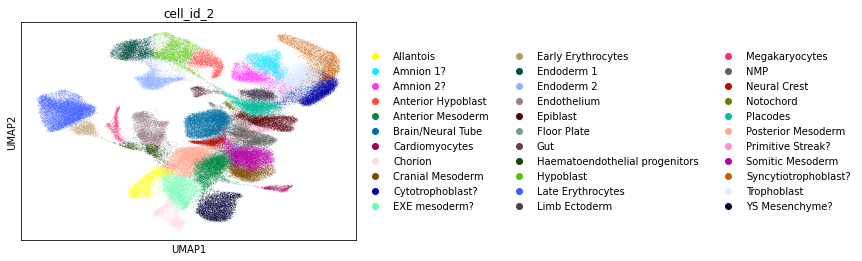

In [42]:
sc.pl.umap(adata, color='cell_id_2')

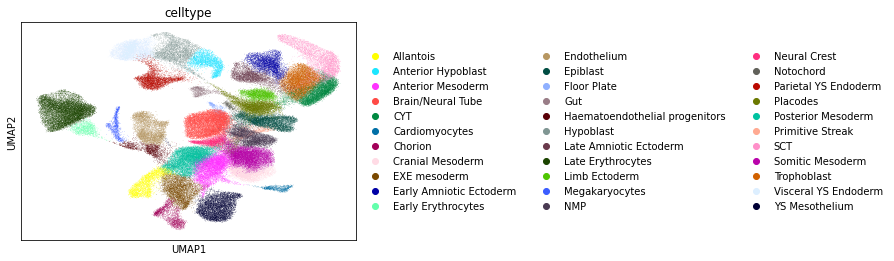

In [43]:
sc.pl.umap(adata, color='celltype')

In [44]:
adata.obs.to_csv('/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_2/RNA/metadata.csv')

### Get Marker genes per celltype

In [16]:
adata

AnnData object with n_obs × n_vars = 146133 × 30725
    obs: 'cell', 'barcode', 'sample', 'stage', 'batch', 'doub.density', 'doublet', 'stripped', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'sizeFactor', 'celltype', 'singler', 'leiden_res1', 'leiden_res2', 'leiden_res1_5', 'leiden_res2_5', 'leiden_res3', 'leiden_res5', 'leiden_res10', 'leiden_res6', 'leiden_res7', 'leiden_res8', 'anatomical_loc', 'day'
    var: 'ensembl_ids'
    uns: 'anatomical_loc_colors', 'celltype_colors', 'draw_graph', 'leiden', 'neighbors', 'singler_colors', 'umap'
    obsm: 'X_draw_graph_fa', 'X_pca', 'X_tsne', 'X_umap'
    layers: 'logcounts'
    obsp: 'connectivities', 'distances'

In [17]:
sc.pp.normalize_total(adata)

In [18]:
adata

AnnData object with n_obs × n_vars = 146133 × 30725
    obs: 'cell', 'barcode', 'sample', 'stage', 'batch', 'doub.density', 'doublet', 'stripped', 'cluster', 'cluster.sub', 'cluster.stage', 'cluster.theiler', 'sizeFactor', 'celltype', 'singler', 'leiden_res1', 'leiden_res2', 'leiden_res1_5', 'leiden_res2_5', 'leiden_res3', 'leiden_res5', 'leiden_res10', 'leiden_res6', 'leiden_res7', 'leiden_res8', 'anatomical_loc', 'day'
    var: 'ensembl_ids'
    uns: 'anatomical_loc_colors', 'celltype_colors', 'draw_graph', 'leiden', 'neighbors', 'singler_colors', 'umap'
    obsm: 'X_draw_graph_fa', 'X_pca', 'X_tsne', 'X_umap'
    layers: 'logcounts'
    obsp: 'connectivities', 'distances'

In [27]:
sc.tl.rank_genes_groups(adata, groupby ='celltype')

/usr/lib/python3.8/site-packages/anndata/_core/anndata.py:1192: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  if is_string_dtype(df[key]) and not is_categorical(df[key])
/usr/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:417: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (


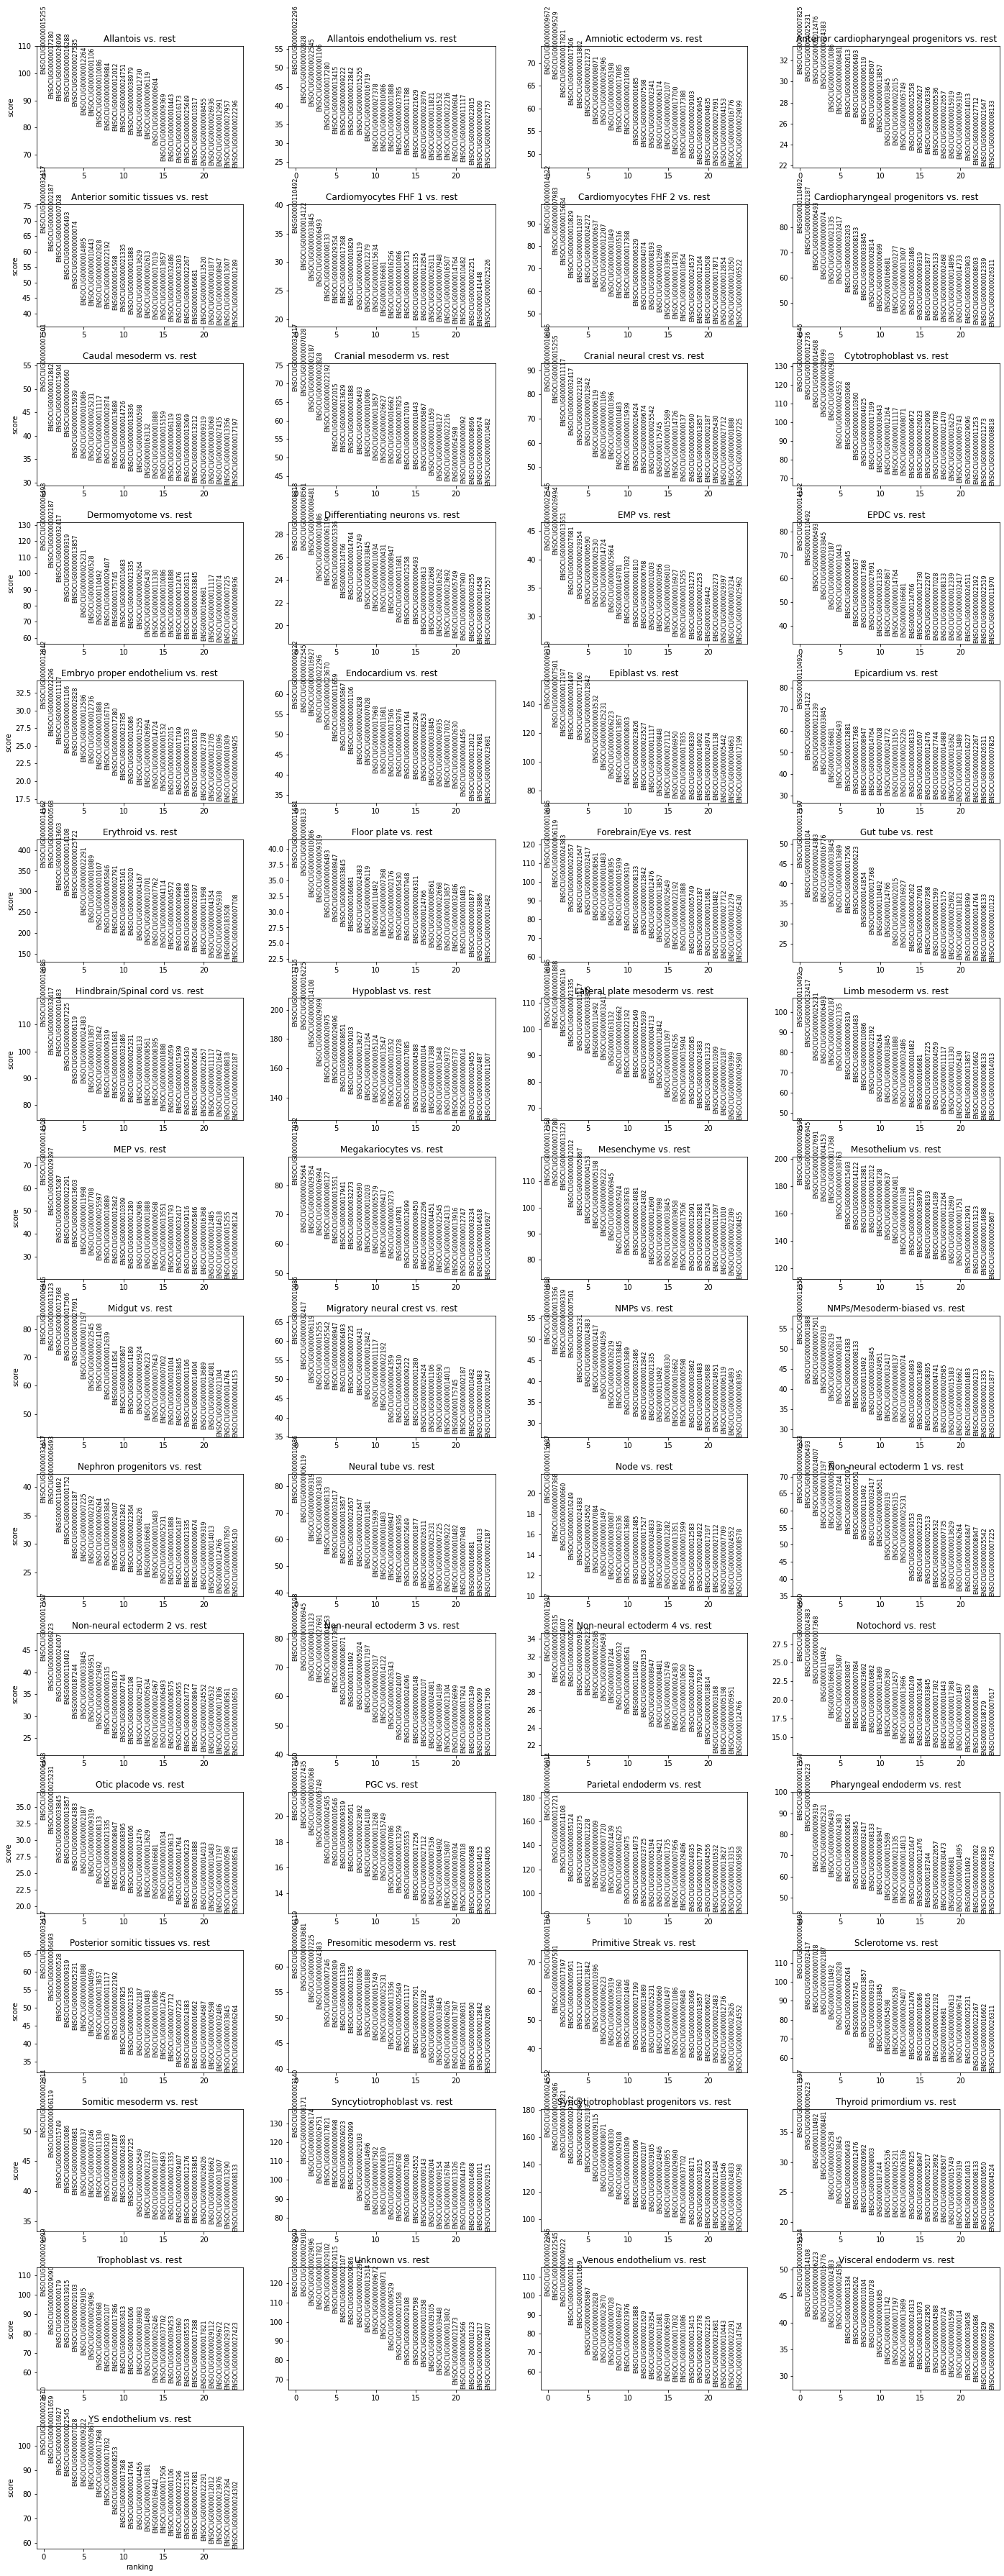

In [28]:
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [35]:
markers = pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(20)

In [36]:
markers.to_csv('/rds/project/rds-SDzz0CATGms/users/bt392/0X_Rabbit_ATAC/RNA/markers.csv')